> # SECTION -2

--- 
- Visualize quantum circuits

- **Visualize quantum measurements**

- Visualize quantum states
---

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> ## Visualize quantum measurements

REFERENCE : https://quantum.cloud.ibm.com/docs/en/guides/visualize-results

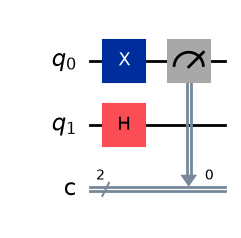

In [3]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.h(1)
qc.measure(0, 0)
qc.draw(output="mpl")

In [18]:

from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.transpiler import generate_preset_pass_manager
# Quantum circuit to make a Bell state
qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)
qc.measure_all()


# execute the quantum circuit
sampler = Sampler()
job = sampler.run([qc])
result = job.result()

print(result)

PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


In [19]:

counts_data=result[0].data.meas.get_counts()

print(counts_data)

{'11': 507, '10': 517}


> # plot_histogram

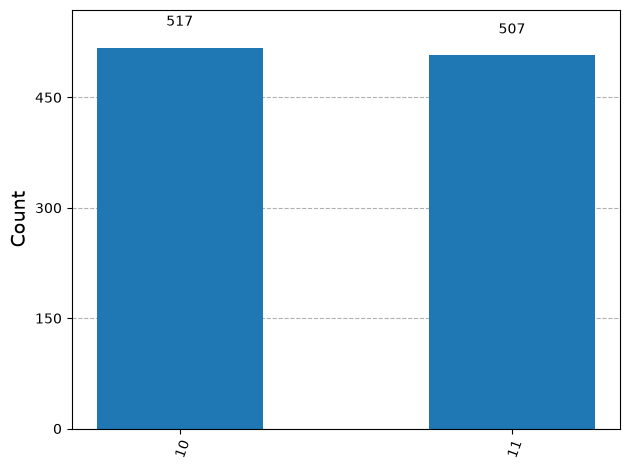

In [20]:
from qiskit.visualization import plot_histogram
plot_histogram(counts_data)

> Example 

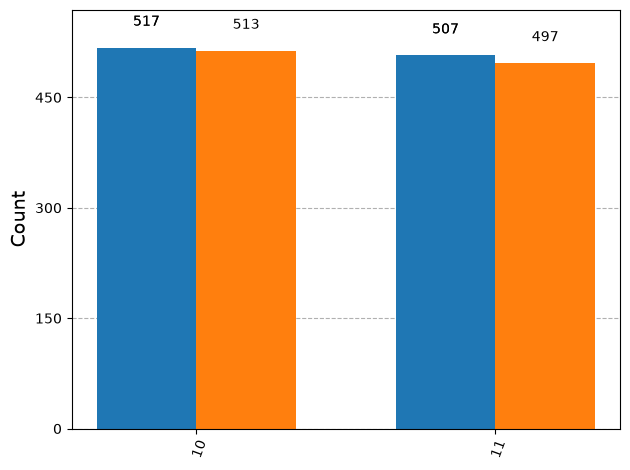

In [23]:

data1={'11': 507, '10': 517}

data2={'11': 497, '10': 513}

plot_histogram([data1,data2])

> OPTIONs in HISTOGRAM

> legend: Provides a label for the executions. It takes a list of strings used to label each execution's results.

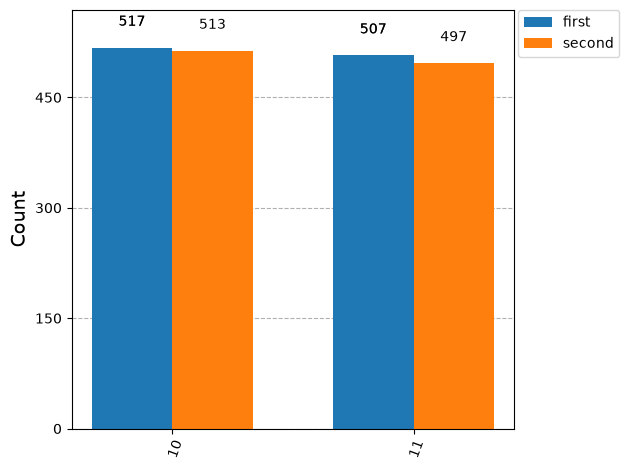

In [24]:
 plot_histogram([data1,data2],legend=["first", "second"])

> sort: Adjusts the order of the bars in the histogram.

> bar_labels: Adjusts whether labels are printed above the bars

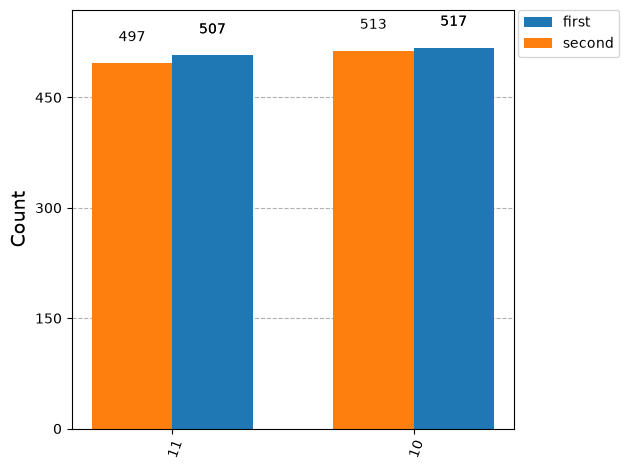

In [29]:
 plot_histogram([data1,data2],legend=["first", "second"], sort="desc")

> # Qiskit does not have a built-in function for plotting Estimator results

In [181]:
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
#Two-qubit operators
H = SparsePauliOp("Z")

print(H)


SparsePauliOp(['Z'],
              coeffs=[1.+0.j])


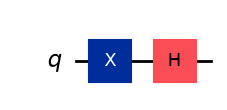

In [189]:
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
qc.draw(output="mpl")

In [190]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

from qiskit_aer import AerSimulator

In [191]:
backend = AerSimulator()
estimator = Estimator(mode=backend)
job = estimator.run([(qc, H)])
result = job.result()
print(f" > Result class: {type(result)}")
print(f" > Expectation value: {result[0].data.evs}")
print(f" > Metadata: {result[0].metadata}")

 > Result class: <class 'qiskit.primitives.containers.primitive_result.PrimitiveResult'>
 > Expectation value: 0.0263671875
 > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}


In [192]:
exp_val = result[0].data.evs

print(f"⟨Z⟩ = {exp_val:.4f}")

⟨Z⟩ = 0.0264



Estimator ⟨Z⟩ = 0.0264 ± 0.0156


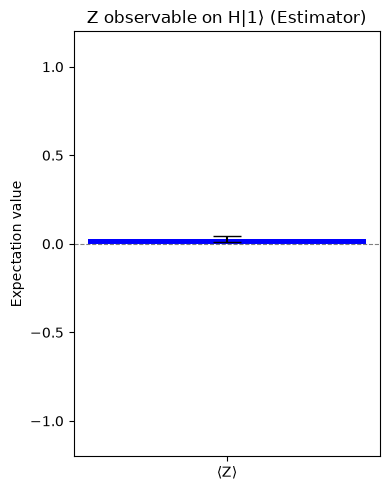

In [199]:
from matplotlib import pyplot as plt
# Plot using Matplotlib

# Estimator results
ev = result[0].data.evs.item()
std =result[0].data.stds.item()
print(f"\nEstimator ⟨Z⟩ = {ev:.4f} ± {std:.4f}")

fig, ax = plt.subplots(figsize=(4, 5))
ax.bar(["⟨Z⟩"], [ev], yerr=[std], capsize=10, color="blue", width=0.4)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(-1.2, 1.2)
ax.set_ylabel("Expectation value")
ax.set_title("Z observable on H|1⟩ (Estimator)")
plt.tight_layout()
plt.show()

In [195]:
exp_val = job.result()[0].data.evs
print(exp_val)

0.0263671875


> # VISUALIZATIONS

REF: https://quantum.cloud.ibm.com/docs/en/api/qiskit/visualization#visualizations

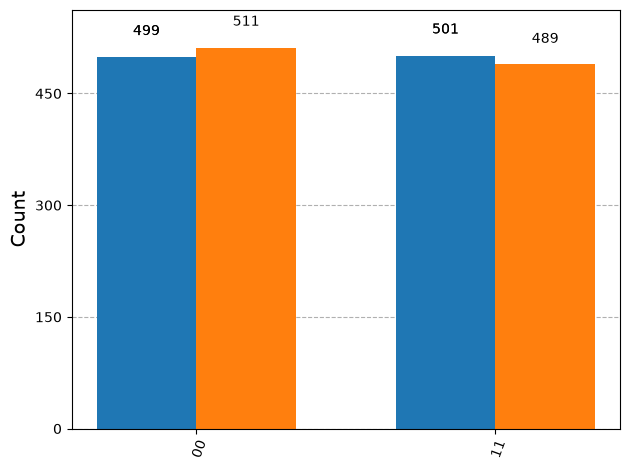

In [201]:
from qiskit.visualization import plot_histogram

counts1 = {'00': 499, '11': 501}
counts2 = {'00': 511, '11': 489}

data = [counts1, counts2]
plot_histogram(data)